<a href="https://colab.research.google.com/github/nehashah2898/AIPI590/blob/main/Adversarial_Patches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 187MB/s]


Target class: 859 -> toaster
Training with 8 images (e.g., [PosixPath('images_for_patch/rand_0.jpg'), PosixPath('images_for_patch/rand_1.jpg'), PosixPath('images_for_patch/rand_10.jpg')])
[0000/900] loss=7.8627  CE=7.8621  TV=0.000664  mean_tgt_p=0.0004
[0020/900] loss=7.9144  CE=7.9143  TV=0.000073  mean_tgt_p=0.0004
[0040/900] loss=7.8269  CE=7.8269  TV=0.000035  mean_tgt_p=0.0004
[0060/900] loss=7.8545  CE=7.8545  TV=0.000029  mean_tgt_p=0.0004
[0080/900] loss=7.8128  CE=7.8128  TV=0.000028  mean_tgt_p=0.0005
[0100/900] loss=7.7546  CE=7.7545  TV=0.000028  mean_tgt_p=0.0005
[0120/900] loss=7.8084  CE=7.8084  TV=0.000027  mean_tgt_p=0.0005
[0140/900] loss=7.7063  CE=7.7063  TV=0.000027  mean_tgt_p=0.0005
[0160/900] loss=7.6524  CE=7.6524  TV=0.000027  mean_tgt_p=0.0005
[0180/900] loss=7.6884  CE=7.6883  TV=0.000027  mean_tgt_p=0.0005
[0200/900] loss=7.8108  CE=7.8107  TV=0.000027  mean_tgt_p=0.0004
[0220/900] loss=7.7166  CE=7.7166  TV=0.000027  mean_tgt_p=0.0005
[0240/900] loss=7.71

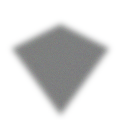

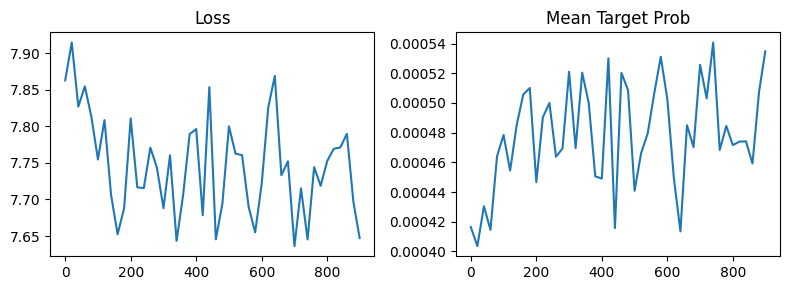

[Trial 0] top1: coral reef (0.1350)


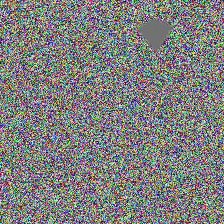

[Trial 1] top1: poncho (0.1806)


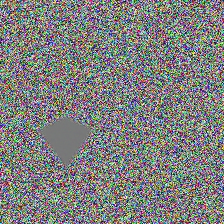

[Trial 2] top1: coral reef (0.0984)


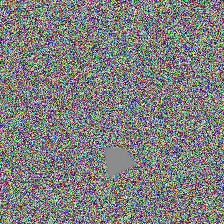

[Trial 3] top1: sea urchin (0.1246)


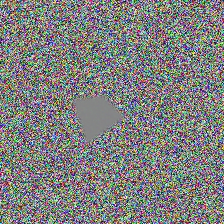

[0000/300] loss=7.1438  CE=7.1431  TV=0.000666  mean_tgt_p=0.0010
[0020/300] loss=7.5376  CE=7.5375  TV=0.000079  mean_tgt_p=0.0009
[0040/300] loss=8.2992  CE=8.2991  TV=0.000041  mean_tgt_p=0.0007
[0060/300] loss=7.1393  CE=7.1393  TV=0.000036  mean_tgt_p=0.0014
[0080/300] loss=7.6724  CE=7.6723  TV=0.000035  mean_tgt_p=0.0011
[0100/300] loss=7.4892  CE=7.4892  TV=0.000034  mean_tgt_p=0.0011
[0120/300] loss=7.4455  CE=7.4454  TV=0.000034  mean_tgt_p=0.0012
[0140/300] loss=7.4035  CE=7.4034  TV=0.000034  mean_tgt_p=0.0013
[0160/300] loss=7.6506  CE=7.6506  TV=0.000034  mean_tgt_p=0.0010
[0180/300] loss=7.6683  CE=7.6683  TV=0.000034  mean_tgt_p=0.0010
[0200/300] loss=7.6539  CE=7.6538  TV=0.000034  mean_tgt_p=0.0008
[0220/300] loss=7.3920  CE=7.3920  TV=0.000033  mean_tgt_p=0.0010
[0240/300] loss=7.5803  CE=7.5803  TV=0.000034  mean_tgt_p=0.0011
[0260/300] loss=7.5295  CE=7.5295  TV=0.000033  mean_tgt_p=0.0010
[0280/300] loss=7.2787  CE=7.2786  TV=0.000034  mean_tgt_p=0.0012
[0299/300]

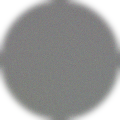

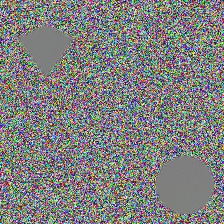

Combined top1: bib 0.0868
Top5:
  bib 0.0868
  poncho 0.0796
  birdhouse 0.0461
  bubble 0.0442
  jigsaw puzzle 0.0389
Wrote adv_patch_out/README.txt


In [1]:

import os, math, random, urllib.request
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from IPython.display import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE   = 224
PATCH_SIZE   = 120
EOT_SAMPLES  = 8
NUM_STEPS    = 900
LR           = 0.12
BATCH_STUB   = 8
TARGET_NAME  = "toaster"

SAVE_DIR = Path("adv_patch_out")
SAVE_DIR.mkdir(exist_ok=True)

weights = models.ResNet34_Weights.IMAGENET1K_V1
model   = models.resnet34(weights=weights).to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

IMAGENET_CLASSES_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes_txt = urllib.request.urlopen(IMAGENET_CLASSES_URL).read().decode("utf-8").splitlines()

if TARGET_NAME in classes_txt:
    TARGET_CLASS = classes_txt.index(TARGET_NAME)
else:
    print(f"[WARN] '{TARGET_NAME}' not found; defaulting to class index 859.")
    TARGET_CLASS = 859
print(f"Target class: {TARGET_CLASS} -> {classes_txt[TARGET_CLASS]}")

preprocess = weights.transforms()

def load_image(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    if img.size != (size, size):
        img = TF.resize(img, [size, size])
    return img

def ensure_train_images():
    """Prepare a small pool of training images in images_for_patch/"""
    folder = Path("images_for_patch")
    folder.mkdir(exist_ok=True)
    jpgs = list(folder.glob("*.jpg"))
    if not jpgs:
        for i in range(12):
            arr = np.random.randint(0, 255, (IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
            Image.fromarray(arr).save(folder / f"rand_{i}.jpg")
    return sorted(list(folder.glob("*.jpg")))

train_paths = ensure_train_images()[:max(1, BATCH_STUB)]
train_pils  = [load_image(str(p)) for p in train_paths]
print(f"Training with {len(train_pils)} images (e.g., {train_paths[:3]})")

def create_patch_tensor(patch_size=PATCH_SIZE, init='random'):
    if init == 'random':
        p = torch.rand(3, patch_size, patch_size, device=device, requires_grad=True)
    else:
        p = torch.full((3, patch_size, patch_size), 0.5, device=device, requires_grad=True)
    return p

def make_shape_mask(patch_size, shape='heart'):
    """Return HxW float mask in [0,1] for sticker shape."""
    mask = Image.new("L", (patch_size, patch_size), 0)
    draw = ImageDraw.Draw(mask)
    if shape == 'circle':
        draw.ellipse((0,0,patch_size-1,patch_size-1), fill=255)
    elif shape == 'star':
        cx, cy = patch_size/2, patch_size/2
        r_outer = patch_size*0.48
        r_inner = r_outer*0.45
        pts = []
        for i in range(10):
            r = r_outer if i%2==0 else r_inner
            ang = math.pi/2 + i*(2*math.pi/10)
            pts.append((cx + math.cos(ang)*r, cy - math.sin(ang)*r))
        draw.polygon(pts, fill=255)
    else:
        w, h = patch_size, patch_size
        draw.polygon([(w*0.5, h*0.2), (w*0.9, h*0.4), (w*0.5, h*0.95), (w*0.1, h*0.4)], fill=255)
    mask = mask.filter(ImageFilter.GaussianBlur(radius=max(1, int(patch_size*0.03))))
    return np.array(mask, dtype=np.float32)/255.0

def brighten_pil(img, factor):
    arr = np.asarray(img).astype(np.float32) * float(factor)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def apply_patch_to_image(img_pil, patch_tensor, mask_np=None,
                         scale_min=0.15, scale_max=0.35, rotate_max=30):
    """Paste a (3,H,W) 0..1 patch onto a PIL image with random transforms."""
    W, H = img_pil.size
    patch_np = (patch_tensor.detach().clamp(0,1).cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)
    patch_pil = Image.fromarray(patch_np)
    mask_img  = Image.fromarray((mask_np*255).astype(np.uint8)) if mask_np is not None else Image.new("L", patch_pil.size, 255)

    scale = random.uniform(scale_min, scale_max)
    size  = (max(1, int(scale*W)), max(1, int(scale*H)))
    patch_pil = patch_pil.resize(size, resample=Image.BILINEAR)
    mask_img  = mask_img.resize(size,  resample=Image.BILINEAR)

    rot = random.uniform(-rotate_max, rotate_max)
    patch_pil = patch_pil.rotate(rot, expand=True, resample=Image.BILINEAR)
    mask_img  = mask_img.rotate(rot,  expand=True, resample=Image.BILINEAR)

    if random.random() < 0.7:
        patch_pil = brighten_pil(patch_pil, random.uniform(0.85, 1.15))

    px = random.randint(0, max(0, W - patch_pil.size[0]))
    py = random.randint(0, max(0, H - patch_pil.size[1]))
    out = img_pil.copy()
    out.paste(patch_pil, (px, py), mask_img.convert("L"))
    return out

def batch_apply_patch_and_preprocess(pil_list, patch_tensor, mask_np=None, eot_samples=EOT_SAMPLES):
    samples = []
    for img in pil_list:
        for _ in range(eot_samples):
            patched = apply_patch_to_image(img, patch_tensor, mask_np)
            t = preprocess(patched)
            t = t.unsqueeze(0)
            samples.append(t.to(device))
    batch = torch.cat(samples, dim=0)
    assert batch.ndim == 4 and batch.shape[1] == 3, f"Bad batch shape: {batch.shape}"
    return batch

ce_loss = nn.CrossEntropyLoss()

def tv_loss(x):
    return (x[:, :, :, :-1] - x[:, :, :, 1:]).abs().mean() + (x[:, :, :-1, :] - x[:, :, 1:, :]).abs().mean()

def train_patch(patch, train_images, mask_np=None, target_class=TARGET_CLASS, steps=NUM_STEPS, lr=LR):
    opt = optim.Adam([patch], lr=lr)
    hist = []
    for step in range(steps):
        opt.zero_grad()
        patch.data.clamp_(0,1)

        batch = batch_apply_patch_and_preprocess(train_images, patch, mask_np, eot_samples=EOT_SAMPLES)
        logits = model(batch)
        target = torch.full((logits.size(0),), int(target_class), device=device, dtype=torch.long)

        loss_ce = ce_loss(logits, target)
        loss_tv = 1e-3 * tv_loss(patch.unsqueeze(0))
        loss = loss_ce + loss_tv
        loss.backward()
        opt.step()
        patch.data.clamp_(0,1)

        if step % 20 == 0 or step == steps-1:
            with torch.no_grad():
                probs = torch.softmax(logits, dim=1)[:, target_class].mean().item()
            print(f"[{step:04d}/{steps}] loss={loss.item():.4f}  CE={loss_ce.item():.4f}  TV={loss_tv.item():.6f}  mean_tgt_p={probs:.4f}")
            hist.append((step, float(loss.item()), float(probs)))
    return patch.detach().cpu(), hist

patch   = create_patch_tensor(PATCH_SIZE, init='random')
mask_np = make_shape_mask(PATCH_SIZE, shape='heart')  # change to 'circle' or 'star' if you wish

trained_patch, history = train_patch(patch, train_pils, mask_np=mask_np,
                                     target_class=TARGET_CLASS, steps=NUM_STEPS, lr=LR)

def save_patch_image(patch_tensor_cpu, mask_np=None, fname=SAVE_DIR/"patch_heart.png"):
    arr = (patch_tensor_cpu.numpy().transpose(1,2,0)*255).astype(np.uint8)
    img = Image.fromarray(arr)
    if mask_np is not None:
        mask_img = Image.fromarray((mask_np*255).astype(np.uint8)).convert("L")
        bg = Image.new("RGB", img.size, (255,255,255))
        bg.paste(img, (0,0), mask_img)
        bg.save(str(fname))
    else:
        img.save(str(fname))
    print("Saved:", fname)
    display(Image.open(str(fname)))

save_patch_image(trained_patch, mask_np=mask_np, fname=SAVE_DIR/"patch_heart.png")


if history:
    steps, losses, probs = zip(*history)
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); plt.plot(steps, losses); plt.title("Loss")
    plt.subplot(1,2,2); plt.plot(steps, probs);  plt.title("Mean Target Prob")
    plt.tight_layout(); plt.show()


def predict_with_patch(img_pil, patch_tensor, mask_np=None, trials=6):
    for i in range(trials):
        patched = apply_patch_to_image(img_pil, patch_tensor, mask_np)
        inp = preprocess(patched).unsqueeze(0).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(inp), dim=1)[0]
            top5v, top5i = torch.topk(probs, 5)
        print(f"[Trial {i}] top1: {classes_txt[top5i[0].item()]} ({top5v[0].item():.4f})")
        display(patched)

test_img = train_pils[0]
predict_with_patch(test_img, trained_patch, mask_np=mask_np, trials=4)


second_name = "soccer ball"
second_idx  = classes_txt.index(second_name) if second_name in classes_txt else 834

patch2   = create_patch_tensor(PATCH_SIZE, init='random')
mask2_np = make_shape_mask(PATCH_SIZE, shape='circle')
patch2_trained, _ = train_patch(patch2, train_pils, mask_np=mask2_np,
                                target_class=second_idx, steps=300, lr=0.15)

save_patch_image(patch2_trained.cpu(), mask_np=mask2_np, fname=SAVE_DIR/"patch_circle.png")


combined = test_img.copy()
p1 = Image.fromarray((trained_patch.numpy().transpose(1,2,0)*255).astype(np.uint8))
m1 = Image.fromarray((mask_np*255).astype(np.uint8)).convert("L")
p1 = p1.resize((int(IMAGE_SIZE*0.32), int(IMAGE_SIZE*0.32))); m1 = m1.resize(p1.size)

p2 = Image.fromarray((patch2_trained.numpy().transpose(1,2,0)*255).astype(np.uint8))
m2 = Image.fromarray((mask2_np*255).astype(np.uint8)).convert("L")
p2 = p2.resize((int(IMAGE_SIZE*0.26), int(IMAGE_SIZE*0.26))); m2 = m2.resize(p2.size)

combined.paste(p1, (10,10), m1)
combined.paste(p2, (IMAGE_SIZE - p2.size[0] - 10, IMAGE_SIZE - p2.size[1] - 10), m2)
display(combined)

with torch.no_grad():
    logits = model(preprocess(combined).unsqueeze(0).to(device))
    probs  = torch.softmax(logits, dim=1)[0]
    top5v, top5i = torch.topk(probs, 5)

print("Combined top1:", classes_txt[top5i[0].item()], f"{top5v[0].item():.4f}")
print("Top5:")
for idx, val in zip(top5i.tolist(), top5v.tolist()):
    print(" ", classes_txt[idx], f"{val:.4f}")


readme = f"""
Adversarial Sticker Patches (ResNet34)

Target #1: {classes_txt[TARGET_CLASS]}  (index {TARGET_CLASS})
Target #2: {classes_txt[second_idx]}    (index {second_idx})

Artifacts:
- adv_patch_out/patch_heart.png  (printable sticker #1)
- adv_patch_out/patch_circle.png (printable sticker #2)

Print tips:
- Print in color on sticker paper; keep square aspect; ~3–8 cm wide works well for webcams.
- Place on objects or hold near the camera; test at https://resnet34-classifier.streamlit.app/
"""
(SAVE_DIR / "README.txt").write_text(readme)
print("Wrote", SAVE_DIR / "README.txt")
